In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Pantheon+ data file: generated by SNANA, taken from the data release page
# standardized, bias-corrected m_B values are in 'm_b_corr' column
df_pplus = pd.read_csv('data/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')

# covariance matrix
cov_file = 'data/Pantheon+SH0ES_STAT+SYS.cov'
cov_data_flat = np.loadtxt(cov_file, skiprows=1)
cov_matrix = cov_data_flat.reshape((len(df_pplus), len(df_pplus)))

# SH0ES labels
df_sh0es_labels = pd.read_csv('data/SH0ES_y_labels.csv')

In [3]:
# merge with SH0ES data 
df_pplus['key'] = df_pplus['CID'].astype(str) + '_' + df_pplus['IDSURVEY'].astype(str)

# extract SN name from y-labels
for i in df_sh0es_labels.index.values:
    label = df_sh0es_labels.loc[i,'label']
    if type(label) != str:
        continue
    if '_' in label:
        ylabel_split = label.split('_')
        
        if len(ylabel_split) == 2:
            df_sh0es_labels.loc[i,'CID'] = ylabel_split[0]
            df_sh0es_labels.loc[i,'IDSURVEY'] = ylabel_split[1]
        elif len(ylabel_split) == 3:
            df_sh0es_labels.loc[i,'calib_host'] = ylabel_split[0]
            df_sh0es_labels.loc[i,'CID'] = ylabel_split[1]
            df_sh0es_labels.loc[i,'IDSURVEY'] = ylabel_split[2]
df_sh0es_labels[df_sh0es_labels['CID'].notna()]

df_sh0es_labels['key'] = df_sh0es_labels['CID'].astype(str) + '_' + df_sh0es_labels['IDSURVEY']
merged = pd.merge(df_pplus, 
                  df_sh0es_labels[['key','calib_host']], on='key', how='inner')
merged.head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD,key,calib_host
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003,2011fe_51,m101
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004,2011fe_56,m101
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036,2012cg_51,n4424
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040,2012cg_56,n4424
4,1981B,50,0.00317,0.00084,0.00350,0.00001,0.00236,0.00001,11.54160,0.613941,...,43.2260,0.376420,0.0732,0.5763,0.0206,0.007,1.0,0.013,1981B_50,n4536


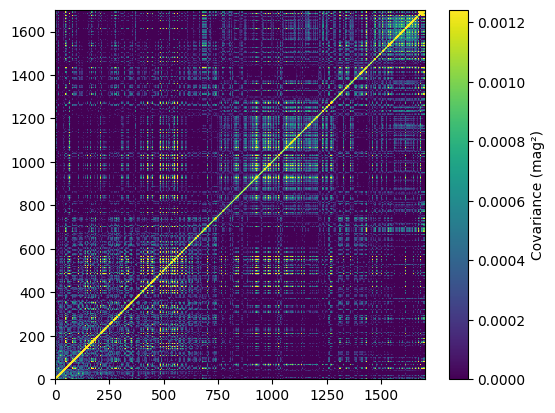

In [4]:
im = plt.imshow(cov_matrix, origin='lower', cmap='viridis',vmin=0,vmax=np.percentile(cov_matrix, 90))
plt.colorbar(im, label='Covariance (mag²)')

## calculate y vector

In [5]:
c = 299792.458 # speed of light in km/s

def q0_jerk_correction(z,q0,j0):
    return 0.5*(1 - q0)*z - (1/6)*(1 - q0 - 3*q0**2 + j0)*z**2

## Select calibrator & Hubble flow SNe

In [6]:
# by default, we follow SH0ES selection of calibrators.
mask_calib = merged['calib_host'].notna()
mask_hf = merged['USED_IN_SH0ES_HF'].isna()

In [7]:
# split data into calibrator SNe and Hubble flow SNe
# here apply whatever cuts you want to apply
SNe_calib = merged[merged['calib_host'].notna()]
SNe_HF    = merged[merged['calib_host'].isna() & merged['zHD'].between(0.023, 0.15)]

# for calib SNe, we simply use the observed m_B
y_calib = SNe_calib['m_b_corr'].values
idx_calib = SNe_calib.index.values

# for Hubble flow SNe, we subtract log10(cz) to get the Hubble intercept
z_HF = SNe_HF['zHD'].values # <-- try changing this to other options: zCMB, zHEL
logcz_term = 5*np.log10(c*z_HF*(1 + q0_jerk_correction(z_HF, q0=-0.55, j0=1))) # <-- try changing the q0 and j0 values to see how it affects the Hubble diagram
y_HF = SNe_HF['m_b_corr'].values - logcz_term - 25

In [8]:
# combine y vectors
y = np.concatenate([y_calib, y_HF])
idx = np.concatenate([idx_calib, SNe_HF.index.values])

# build labels DataFrame  (matches format expected by demo_mu_to_H0.ipynb)
# calibrators: label = "{host}_{CID}_{IDSURVEY}", type = "CAL"
calib_labels = pd.DataFrame({
    'orig_index': SNe_calib.index.values,
    'label': (SNe_calib['calib_host'].str.lower() + '_' +
              SNe_calib['CID'].astype(str) + '_' +
              SNe_calib['IDSURVEY'].astype(str)).values,
    'type': 'CAL',
    'host': SNe_calib['calib_host'].str.lower().values,
})

# Hubble-flow SNe: label = "{CID}_{IDSURVEY}", type = "HF"
hf_labels = pd.DataFrame({
    'orig_index': SNe_HF.index.values,
    'label': (SNe_HF['CID'].astype(str) + '_' +
              SNe_HF['IDSURVEY'].astype(str)).values,
    'type': 'HF',
    'host': np.nan,
})

labels = pd.concat([calib_labels, hf_labels], ignore_index=True)
print(f"Calibrators: {(labels['type']=='CAL').sum()}, HF SNe: {(labels['type']=='HF').sum()}")
labels.head()

Calibrators: 75, HF SNe: 277


,orig_index,label,type,host
0,0,m101_2011fe_51,CAL,m101
1,1,m101_2011fe_56,CAL,m101
2,2,n4424_2012cg_51,CAL,n4424
3,3,n4424_2012cg_56,CAL,n4424
4,4,n4536_1981B_50,CAL,n4536


## Save outputs for `demo_mu_to_H0.ipynb`

Extracts the rows/columns of the full covariance matrix that correspond to the selected SNe, then saves the three files the demo notebook expects:
- `data/custom_y.npy` — y vector
- `data/custom_C.npy` — covariance submatrix
- `data/custom_labels.csv` — row metadata

In [9]:
# extract the covariance submatrix for the selected rows/columns
C = cov_matrix[np.ix_(idx, idx)]

# save
np.save('data/custom_y.npy', y)
np.save('data/custom_C.npy', C)
labels.to_csv('data/custom_labels.csv', index=False)

print(f"Saved {len(y)} rows.")
print(f"  custom_y.npy   : shape {y.shape}")
print(f"  custom_C.npy   : shape {C.shape}")
print(f"  custom_labels.csv: {len(labels)} rows")

Saved 352 rows.
  custom_y.npy   : shape (352,)
  custom_C.npy   : shape (352, 352)
  custom_labels.csv: 352 rows
